# Milestone 1: Week 4 - Logistic Regression and Feature Scaling

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
random_state = 42

In [3]:
cancer_deaths = pd.read_csv("..\Processed Data\cdc_cancer_deaths_encoded.csv")
cancer_deaths.head()

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
cancer_deaths.columns.tolist()

['AGE',
 'CAUSE_RECODE_113',
 'DATA_YEAR',
 'EDUCATION_CODED',
 'HISPANIC_CODED',
 'MANNER_OF_DEATH_CODED',
 'MONTH_OF_DEATH',
 'PLACE_OF_DEATH_CODED',
 'RESIDENT_STATUS_CODED',
 'WEEKDAY_OF_DEATH',
 'SEX_Female',
 'SEX_Male',
 'SEX_CODED_F',
 'RACE_AIAN',
 'RACE_Asian',
 'RACE_Black',
 'RACE_Hispanic',
 'RACE_Multiracial',
 'RACE_NHOPI',
 'RACE_White',
 'ETHNIC_GROUP_AIAN and Asian',
 'ETHNIC_GROUP_AIAN and NHOPI',
 'ETHNIC_GROUP_AIAN and White',
 'ETHNIC_GROUP_AIAN, Asian and NHOPI',
 'ETHNIC_GROUP_AIAN, Asian and White',
 'ETHNIC_GROUP_AIAN, Asian, NHOPI and White',
 'ETHNIC_GROUP_AIAN, NHOPI and White',
 'ETHNIC_GROUP_American Indian or Alaskan Native (AIAN)',
 'ETHNIC_GROUP_Asian Indian',
 'ETHNIC_GROUP_Asian and NHOPI',
 'ETHNIC_GROUP_Asian and White',
 'ETHNIC_GROUP_Asian, NHOPI and White',
 'ETHNIC_GROUP_Black and AIAN',
 'ETHNIC_GROUP_Black and Asian',
 'ETHNIC_GROUP_Black and Native Hawaiian or Other Pacific Islander (NHOPI)',
 'ETHNIC_GROUP_Black and White',
 'ETHNIC_GROUP_B

#### Logistic Regression

Cancer Deaths - Female

<Axes: xlabel='SEX_Female', ylabel='count'>

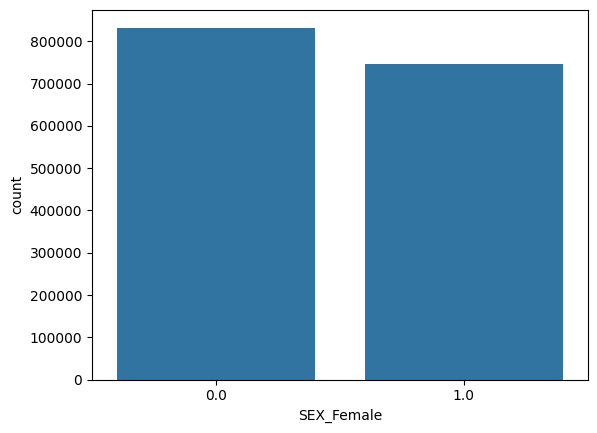

In [ ]:
sns.countplot(x='SEX_Female', data=cancer_deaths)

In [ ]:
cancer_deaths['AGE'].min(), cancer_deaths['AGE'].max()

(np.float64(9.886683397977032e-05), np.float64(111.0))

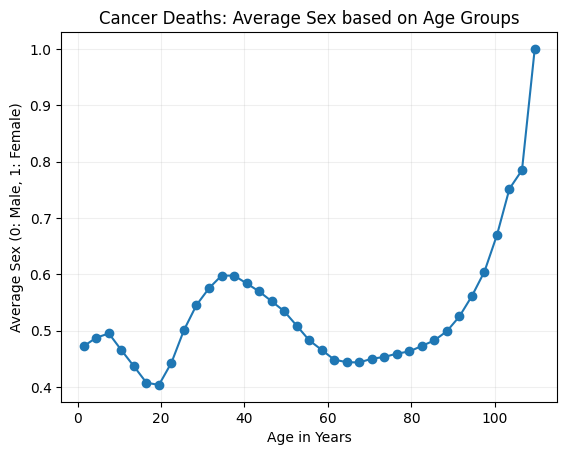

In [ ]:
# Displaying average sex based on age bins
# 0 to 111, so 37 bins gets 3 year bins
cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['SEX_Female'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['SEX_Female'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average Sex (0: Male, 1: Female)")
plt.title("Cancer Deaths: Average Sex based on Age Groups")
plt.grid(True, alpha=0.2)

In [4]:
X = cancer_deaths.drop(columns=['SEX_Female', 'SEX_Male', 'SEX_CODED_F']) # dropping female, male, sex coded, that will lead to data leakage
y = cancer_deaths['SEX_Female']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Baseline models using different regulaization techniques

In [ ]:
# ----------------------------------
# cross-entropy / unregularized model
# ----------------------------------
ce_model = LogisticRegression(penalty=None, solver='saga', max_iter=1000, n_jobs=-1, tol=1e-3, random_state=random_state).fit(X_train_scaled, y_train)
ce_pred = ce_model.predict(X_test_scaled)
ce_prob = ce_model.predict_proba(X_test_scaled)[:, 1]
ce_acc = accuracy_score(y_test, ce_pred)
ce_l1 = log_loss(y_test, ce_prob)

In [ ]:
print(f"  Cross-entropy (sklearn):     accuracy = {ce_acc:.3f}, log loss = {ce_l1:.3f}")

  Cross-entropy (sklearn):     accuracy = 0.725, log loss = 0.506


In [ ]:
# ----------------------------------
# Lasso regularization model (L1)
# ----------------------------------
lasso_model = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, n_jobs=-1, tol=1e-3, random_state=random_state).fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_prob = lasso_model.predict_proba(X_test_scaled)[:, 1]
lasso_acc = accuracy_score(y_test, lasso_pred)
lasso_l1 = log_loss(y_test, lasso_prob)

In [ ]:
print(f"  Lasso (sklearn):             accuracy = {lasso_acc:.3f}, log loss = {lasso_l1:.3f}")

  Lasso (sklearn):             accuracy = 0.725, log loss = 0.506


In [ ]:
# ----------------------------------
# Ridge regularization model (L2)
# ----------------------------------
ridge_model = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, n_jobs=-1, tol=1e-3, random_state=random_state).fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_prob = ridge_model.predict_proba(X_test_scaled)[:, 1]
ridge_acc = accuracy_score(y_test, ridge_pred)
ridge_l1 = log_loss(y_test, ridge_prob)

In [ ]:
print(f"  Ridge (sklearn):             accuracy = {ridge_acc:.3f}, log loss = {ridge_l1:.3f}")

  Ridge (sklearn):             accuracy = 0.725, log loss = 0.506


In [ ]:
# ============================================================
# Print results
# ============================================================
print("\n================ TEST-SET RESULTS =================")
print(f"  Cross-entropy (sklearn):     accuracy = {ce_acc:.3f}, log loss = {ce_l1:.3f}")
print(f"  Lasso (sklearn):             accuracy = {lasso_acc:.3f}, log loss = {lasso_l1:.3f}")
print(f"  Ridge (sklearn):             accuracy = {ridge_acc:.3f}, log loss = {ridge_l1:.3f}")


================ TEST-SET RESULTS =================
  Cross-entropy (sklearn):     accuracy = 0.725, log loss = 0.506
  Lasso (sklearn):             accuracy = 0.725, log loss = 0.506
  Ridge (sklearn):             accuracy = 0.725, log loss = 0.506


Without tuning the parameters to set how strong the regularizations are, the models are identical accuracy and log loss. In order to determine which model is best for this dataset, I will use GridSearchCV to hypertune the models.

[Used Gemini to debug value error](https://share.gemini.google/A7X5mMjyizDI)

##### Testing hyperparameters for each model to see if we can improve the model and see which regularization technique is best for this data

In [11]:
len(cancer_deaths)

1578489

In [7]:
# Using a subset of the training data in order to run the hyperparameter search due to the massive size of my dataset (1.5M rows)

X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=0.10,
    stratify=y_train, # using stratify in order to maintain the same 0/1 balance as the original training data
    random_state=random_state
)

In [16]:
param_grid = {
    'C': [0.01, 0.03, 0.1, 0.3, 1, 10]
}

# ----------------------------------
# Lasso regularization model (L1) - Reducing max_iter to save RAM
# ----------------------------------
lasso_model_CV = LogisticRegression(penalty='l1', solver='saga', max_iter=100, tol=1e-3, random_state=random_state)
lasso_grid_search = GridSearchCV(
    estimator=lasso_model_CV,
    param_grid=param_grid,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1
)

print(f"Running Grid Search on {list(param_grid.keys())}\n")

print(f"Tuning Lasso on downsampled subset ({X_tune.shape[0]:,.0f} rows)\n")
lasso_grid_search.fit(X_tune, y_tune)

lasso_best_C = lasso_grid_search.best_params_['C']
lasso_best_score = -lasso_grid_search.best_score_

print(f"--> Optimal C Value Found: {lasso_best_C}")

Running Grid Search on ['C']

Tuning Lasso on downsampled subset (126,279 rows)

--> Optimal C Value Found: 10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [22]:
print(f"\nTraining final Lasso model on full training split ({len(X_train_scaled):,.0f} rows) using C={lasso_best_C}...")

lasso_final_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=lasso_best_C,
    max_iter=1000,
    tol=1e-3,
    random_state=random_state
).fit(X_train_scaled, y_train)

lasso_test_prob = lasso_final_model.predict_proba(X_test_scaled)[:, 1]
lasso_test_pred = lasso_final_model.predict(X_test_scaled)

print("\n================ FINAL LASSO RESULTS ================")
print(f"Lasso Test Accuracy: {accuracy_score(y_test, lasso_test_pred):.3f}")
print(f"Lasso Test Log Loss: {log_loss(y_test, lasso_test_prob):.3f}")


Training final Lasso model on full training split (1,262,791 rows) using C=10...

================ FINAL LASSO RESULTS ================
Lasso Test Accuracy: 0.725
Lasso Test Log Loss: 0.506


In [8]:
param_grid = {
    'C': [0.01, 0.03, 0.1, 0.3, 1, 10]
}

# ----------------------------------
# Ridge regularization model (L2)
# ----------------------------------
ridge_model_CV = LogisticRegression(penalty='l2', solver='saga', max_iter=100, tol=1e-3, random_state=random_state)
ridge_grid_search = GridSearchCV(
    estimator=ridge_model_CV,
    param_grid=param_grid,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1
)

print(f"Running Grid Search on {list(param_grid.keys())}\n")

print(f"Tuning Ridge on downsampled subset ({X_tune.shape[0]:,.0f} rows)\n")
ridge_grid_search.fit(X_tune, y_tune)

ridge_best_C = ridge_grid_search.best_params_['C']
ridge_best_score = -ridge_grid_search.best_score_

print(f"--> Optimal C Value Found: {ridge_best_C}")

Running Grid Search on ['C']

Tuning Ridge on downsampled subset (126,279 rows)

--> Optimal C Value Found: 10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [9]:
print(f"\nTraining final Ridge model on full training split ({len(X_train_scaled):,.0f} rows) using C={ridge_best_C}...")

ridge_final_model = LogisticRegression(
    penalty='l2',
    solver='saga',
    C=ridge_best_C,
    max_iter=1000,
    tol=1e-3,
    random_state=random_state
).fit(X_train_scaled, y_train)

ridge_test_prob = ridge_final_model.predict_proba(X_test_scaled)[:, 1]
ridge_test_pred = ridge_final_model.predict(X_test_scaled)

print("\n================ FINAL RIDGE RESULTS ================")
print(f"Ridge Test Accuracy: {accuracy_score(y_test, ridge_test_pred):.3f}")
print(f"Ridge Test Log Loss: {log_loss(y_test, ridge_test_prob):.3f}")


Training final Ridge model on full training split (1,262,791 rows) using C=10...

================ FINAL RIDGE RESULTS ================
Ridge Test Accuracy: 0.725
Ridge Test Log Loss: 0.506


Interestingly, the accuracy and log loss did not improve or get worse at all for each model after tuning C. This may be due to a limitation in the data rather than the algorithms. First, I will try to make the tolerance lower to see if that changes anything.

In [10]:
print(f"\nTraining final Ridge model on full training split ({len(X_train_scaled):,.0f} rows) using C=10 and lower tol=1e-4")

ridge_final_model_v2 = LogisticRegression(
    penalty='l2',
    solver='lbfgs', # switching from saga to see if lbfgs solver runs faster or if the tol is too low
    C=10,
    max_iter=1000,
    tol=1e-4,
    random_state=random_state
).fit(X_train_scaled, y_train)

ridge_test_prob_v2 = ridge_final_model_v2.predict_proba(X_test_scaled)[:, 1]
ridge_test_pred_v2 = ridge_final_model_v2.predict(X_test_scaled)

print("\n================ FINAL RIDGE RESULTS ================")
print(f"Ridge Test Accuracy: {accuracy_score(y_test, ridge_test_pred_v2):.3f}")
print(f"Ridge Test Log Loss: {log_loss(y_test, ridge_test_prob_v2):.3f}")


Training final Ridge model on full training split (1,262,791 rows) using C=10 and lower tol=1e-4

================ FINAL RIDGE RESULTS ================
Ridge Test Accuracy: 0.725
Ridge Test Log Loss: 0.506


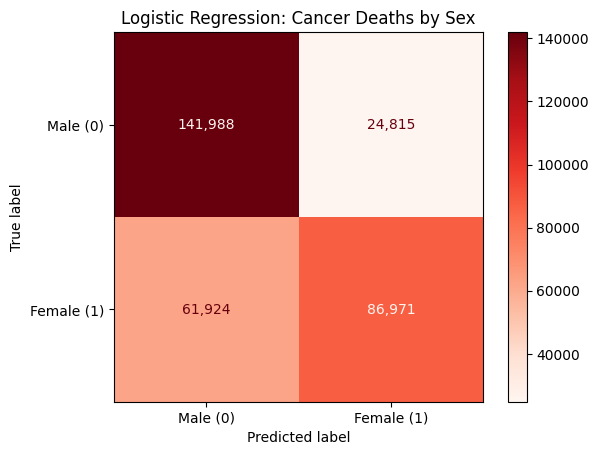

In [16]:
cm = confusion_matrix(y_test, ridge_test_pred_v2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Male (0)', 'Female (1)'])
disp.plot(cmap='Reds', values_format=',.0f')
plt.title('Logistic Regression: Cancer Deaths by Sex')
plt.show()

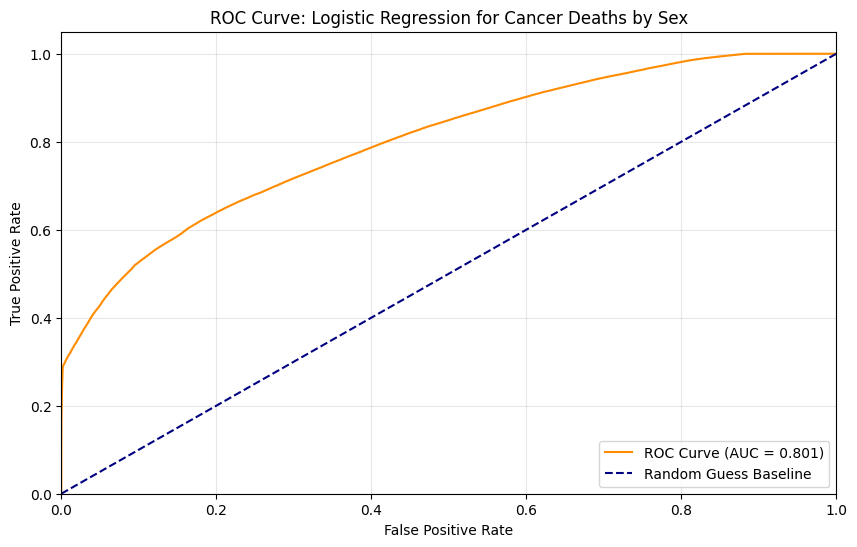

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, ridge_test_prob_v2)
auc_score = roc_auc_score(y_test, ridge_test_prob_v2)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess Baseline')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression for Cancer Deaths by Sex')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

After running logistic regression on this dataset, we can see that the majority of the predictions were true positives and true negatives. However, there is still a significant amount of false positives and false negatives. The accuracy is 72.5% with a log loss of 0.506. Hypertuning this model was not very successful as there were no improvements in predictive power from the unregularized models to the regularized (L1 and L2 models) with hypertuning C, the strength of regularization.

The final model was able to successfully predict female cancer mortaltities at a rate of 77.8% and male cancer mortalities at a rate of 69.6%.

Success rates by sex = $TP/(TP + FP)$

The ROC Curve with an AUC of 0.801 implies that the final model has very strong capability in making predictions instead of random guessing or weak predictive power where AUC = 0.5.

Below are more binned categorical features vs `AGE` that could be worth exploring in the future.

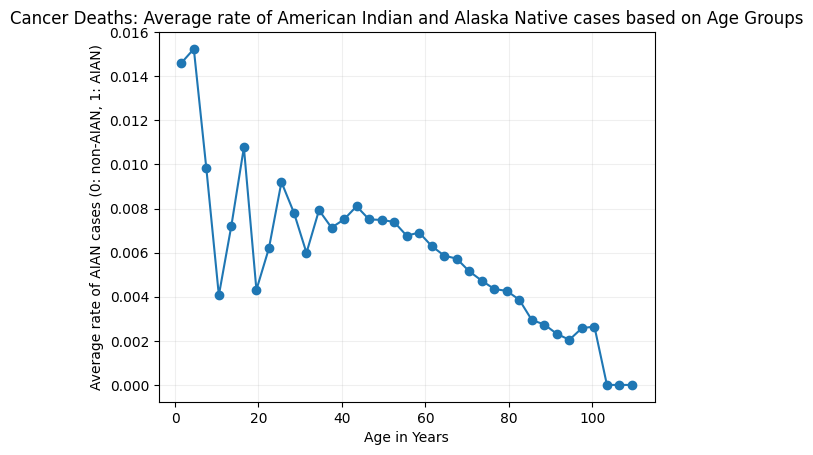

In [ ]:
# Displaying average rate of American Indian and Alaska Native cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_AIAN'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_AIAN'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of AIAN cases (0: non-AIAN, 1: AIAN)")
plt.title("Cancer Deaths: Average rate of American Indian and Alaska Native cases based on Age Groups")
plt.grid(True, alpha=0.2)

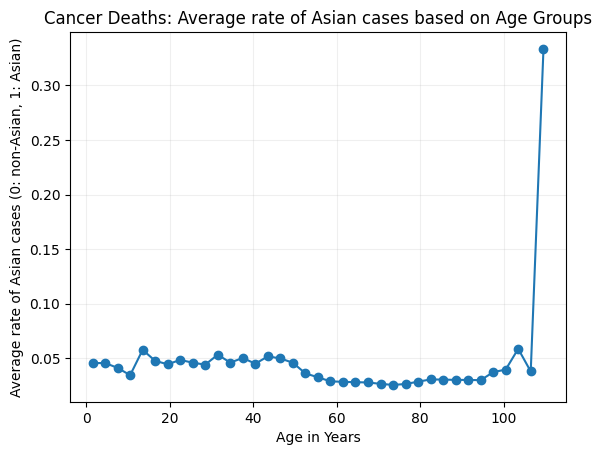

In [ ]:
# Displaying average rate of Asian cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_Asian'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_Asian'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of Asian cases (0: non-Asian, 1: Asian)")
plt.title("Cancer Deaths: Average rate of Asian cases based on Age Groups")
plt.grid(True, alpha=0.2)

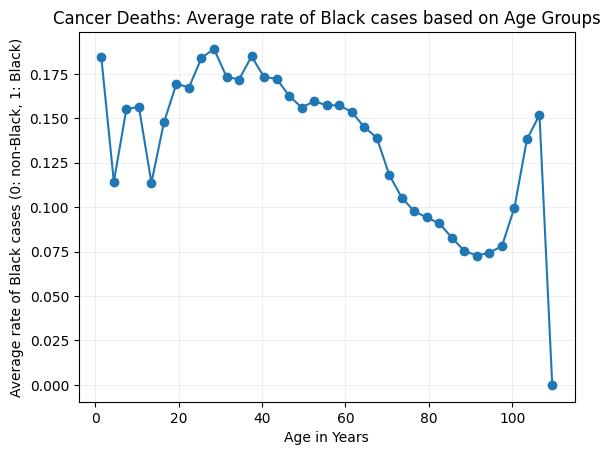

In [ ]:
# Displaying average rate of Black cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_Black'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_Black'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of Black cases (0: non-Black, 1: Black)")
plt.title("Cancer Deaths: Average rate of Black cases based on Age Groups")
plt.grid(True, alpha=0.2)

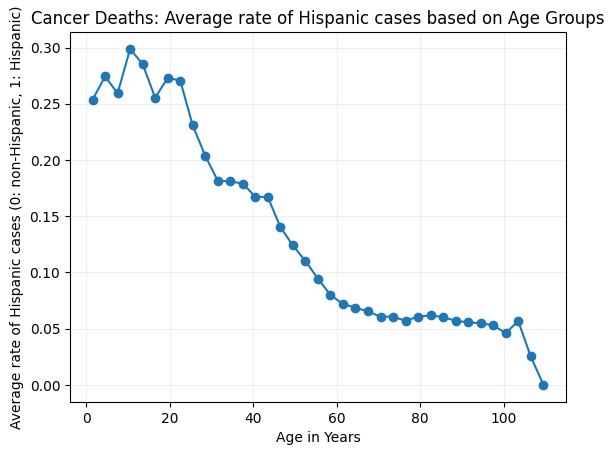

In [ ]:
# Displaying average rate of Hispanic cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_Hispanic'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_Hispanic'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of Hispanic cases (0: non-Hispanic, 1: Hispanic)")
plt.title("Cancer Deaths: Average rate of Hispanic cases based on Age Groups")
plt.grid(True, alpha=0.2)

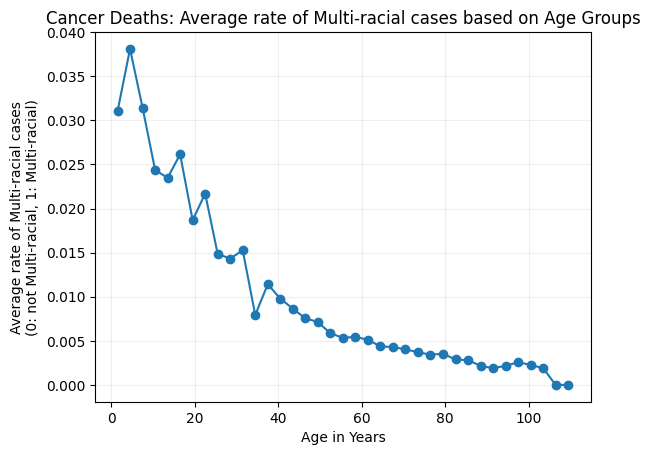

In [ ]:
# Displaying average rate of Multi-racial cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_Multiracial'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_Multiracial'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of Multi-racial cases\n(0: not Multi-racial, 1: Multi-racial)")
plt.title("Cancer Deaths: Average rate of Multi-racial cases based on Age Groups")
plt.grid(True, alpha=0.2)

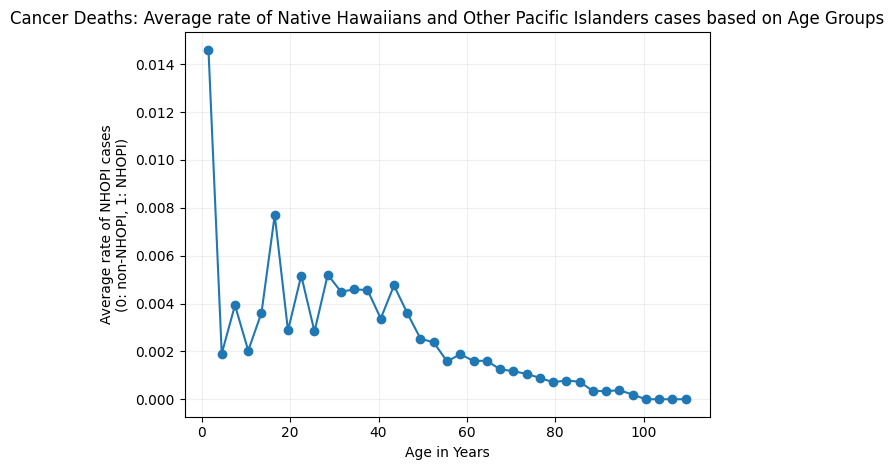

In [ ]:
# Displaying average rate of Native Hawaiians and Other Pacific Islanders cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_NHOPI'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_NHOPI'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of NHOPI cases\n(0: non-NHOPI, 1: NHOPI)")
plt.title("Cancer Deaths: Average rate of Native Hawaiians and Other Pacific Islanders cases based on Age Groups")
plt.grid(True, alpha=0.2)
plt.tight_layout()

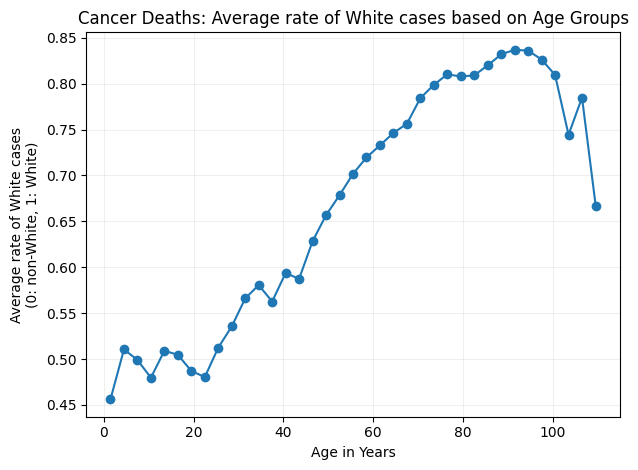

In [ ]:
# Displaying average rate of White cases based on age bins

cancer_deaths['age_bin'] = pd.cut(cancer_deaths['AGE'], bins=37, include_lowest=True, right=False)
age_binned = cancer_deaths.groupby("age_bin", observed=False)['RACE_White'].mean().reset_index()

age_bin_centers = []
for i in age_binned['age_bin']:
    age_bin_centers.append((i.left + i.right) / 2)

plt.plot(age_bin_centers, age_binned['RACE_White'], marker='o')
plt.xlabel("Age in Years")
plt.ylabel("Average rate of White cases\n(0: non-White, 1: White)")
plt.title("Cancer Deaths: Average rate of White cases based on Age Groups")
plt.grid(True, alpha=0.2)
plt.tight_layout()